# Project 02: Heart Disease Prediction Using Machine Learning

## Pluto Academy AI & ML Internship

### Objective
The objective of this project is to build and evaluate machine learning models that can predict whether a patient has heart disease based on medical attributes.

### Dataset
Heart Disease Dataset from Kaggle

### Algorithms Used
1. Logistic Regression
2. Random Forest Classifier
3. K-Nearest Neighbors (KNN)

### Author
Monika

# Step 1: Import Required Libraries

In this step, all required Python libraries for data analysis, visualization, preprocessing, model building, and evaluation are imported.

In [101]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

# Step 2: Load Dataset

The dataset is loaded into a Pandas DataFrame for further analysis and preprocessing.

In [102]:
df = pd.read_csv("heart.csv")

df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


# Step 3: Dataset Overview

Understanding the structure, dimensions, and statistical summary of the dataset.

In [103]:
df.shape

(1025, 14)

In [104]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


In [105]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,1025.000000,1025.000000,1025.000000,1025.000000,1025.00000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000
mean,54.434146,0.695610,0.942439,131.611707,246.00000,0.149268,0.529756,149.114146,0.336585,1.071512,1.385366,0.754146,2.323902,0.513171
std,9.072290,0.460373,1.029641,17.516718,51.59251,0.356527,0.527878,23.005724,0.472772,1.175053,0.617755,1.030798,0.620660,0.500070
min,29.000000,0.000000,0.000000,94.000000,126.00000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,0.000000,120.000000,211.00000,0.000000,0.000000,132.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,56.000000,1.000000,1.000000,130.000000,240.00000,0.000000,1.000000,152.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,275.00000,0.000000,1.000000,166.000000,1.000000,1.800000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.00000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


# Step 4: Missing Value Analysis

Checking whether the dataset contains missing values that require treatment before model training.

In [106]:
df.isnull().sum()

,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


### Observation

No missing values were found in the dataset. Therefore, no imputation techniques were required.

# Duplicate Record Analysis

The dataset was checked for duplicate records to ensure unbiased model evaluation.

A large number of duplicate rows were identified and removed before model training.

In [107]:
print("Shape Before Removing Duplicates:", df.shape)

duplicates = df.duplicated().sum()
print("Duplicate Rows:", duplicates)

df = df.drop_duplicates()

print("Shape After Removing Duplicates:", df.shape)

Shape Before Removing Duplicates: (1025, 14)
Duplicate Rows: 723
Shape After Removing Duplicates: (302, 14)


# Step 5: Target Variable Analysis

The target variable indicates whether a patient has heart disease or not.

In [108]:
df['target'].value_counts()

,count
target,
1,164
0,138


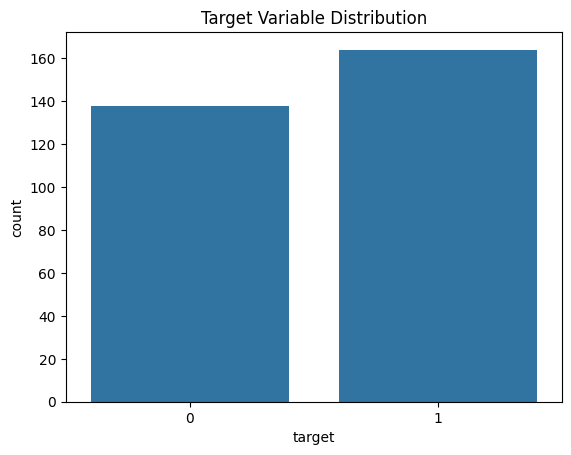

In [109]:
sns.countplot(x='target', data=df)

plt.title("Target Variable Distribution")

plt.show()

# Step 6: Correlation Analysis

Correlation analysis helps identify relationships between variables and determine which features contribute most to prediction.

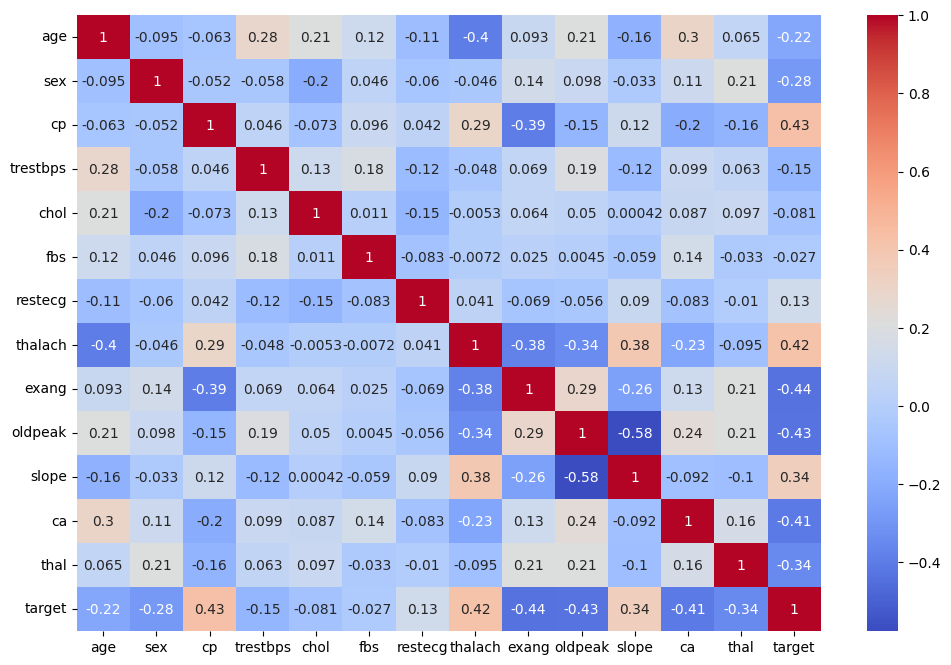

In [110]:
plt.figure(figsize=(12,8))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.show()

In [111]:
corr_target = df.corr()['target']

corr_target.sort_values(ascending=False)

,target
target,1.000000
cp,0.432080
thalach,0.419955
slope,0.343940
restecg,0.134874
fbs,-0.026826
chol,-0.081437
trestbps,-0.146269
age,-0.221476
sex,-0.283609


### Feature Engineering

Features showing stronger relationships with the target variable were selected for model training. Weakly correlated features may introduce noise and reduce model performance.

In [112]:
selected_features = [
    'age',
    'sex',
    'cp',
    'thalach',
    'exang',
    'oldpeak',
    'slope',
    'ca',
    'thal'
]

X = df[selected_features]

y = df['target']

# Step 7: Train-Test Split

The dataset is divided into training and testing sets using an 80:20 ratio.

In [113]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

# Step 8: Feature Scaling

Standardization ensures all features contribute equally to distance-based algorithms such as KNN.

In [114]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

# Step 9: Model Training

Three machine learning algorithms are trained and compared.

1. Logistic Regression
2. Random Forest
3. K-Nearest Neighbors

In [115]:
lr = LogisticRegression()

lr.fit(X_train_scaled, y_train)

y_pred_lr = lr.predict(X_test_scaled)

In [116]:
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

In [117]:
knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train_scaled, y_train)

y_pred_knn = knn.predict(X_test_scaled)

# Step 10: Model Evaluation

The models are evaluated using:

- Accuracy
- Precision
- Recall
- F1 Score

In [118]:
comparison = pd.DataFrame({
    'Model':[
        'Logistic Regression',
        'Random Forest',
        'KNN'
    ],

    'Accuracy':[
        accuracy_score(y_test,y_pred_lr),
        accuracy_score(y_test,y_pred_rf),
        accuracy_score(y_test,y_pred_knn)
    ],

    'Precision':[
        precision_score(y_test,y_pred_lr),
        precision_score(y_test,y_pred_rf),
        precision_score(y_test,y_pred_knn)
    ],

    'Recall':[
        recall_score(y_test,y_pred_lr),
        recall_score(y_test,y_pred_rf),
        recall_score(y_test,y_pred_knn)
    ],

    'F1 Score':[
        f1_score(y_test,y_pred_lr),
        f1_score(y_test,y_pred_rf),
        f1_score(y_test,y_pred_knn)
    ]
})

comparison

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.852459,0.794118,0.931034,0.857143
1,Random Forest,0.852459,0.812500,0.896552,0.852459
2,KNN,0.836066,0.787879,0.896552,0.838710


# Detailed Classification Reports

In [119]:
print("========== Logistic Regression ==========")
print(classification_report(y_test, y_pred_lr))

print("\n========== Random Forest ==========")
print(classification_report(y_test, y_pred_rf))

print("\n========== KNN ==========")
print(classification_report(y_test, y_pred_knn))

========== Logistic Regression ==========
              precision    recall  f1-score   support

           0       0.93      0.78      0.85        32
           1       0.79      0.93      0.86        29

    accuracy                           0.85        61
   macro avg       0.86      0.86      0.85        61
weighted avg       0.86      0.85      0.85        61


========== Random Forest ==========
              precision    recall  f1-score   support

           0       0.90      0.81      0.85        32
           1       0.81      0.90      0.85        29

    accuracy                           0.85        61
   macro avg       0.85      0.85      0.85        61
weighted avg       0.86      0.85      0.85        61


========== KNN ==========
              precision    recall  f1-score   support

           0       0.89      0.78      0.83        32
           1       0.79      0.90      0.84        29

    accuracy                           0.84        61
   macro avg       0.8

In [120]:
print("Model Comparison Results")
comparison.sort_values(by='Accuracy', ascending=False)

Model Comparison Results


,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.852459,0.794118,0.931034,0.857143
1,Random Forest,0.852459,0.812500,0.896552,0.852459
2,KNN,0.836066,0.787879,0.896552,0.838710


# Step 11: Best Model Selection

The model with the highest Accuracy and F1 Score is selected as the best performing model.

In [121]:
comparison.sort_values(
    by='Accuracy',
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.852459,0.794118,0.931034,0.857143
1,Random Forest,0.852459,0.812500,0.896552,0.852459
2,KNN,0.836066,0.787879,0.896552,0.838710


# Step 12: Feature Importance Analysis

Feature importance helps explain which variables contribute most to the prediction.

In [122]:
importance = pd.DataFrame({
    'Feature':X.columns,
    'Importance':rf.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

importance

,Feature,Importance
2,cp,0.183301
3,thalach,0.161723
5,oldpeak,0.150406
0,age,0.131508
8,thal,0.114955
7,ca,0.112662
4,exang,0.056069
6,slope,0.046029
1,sex,0.043347


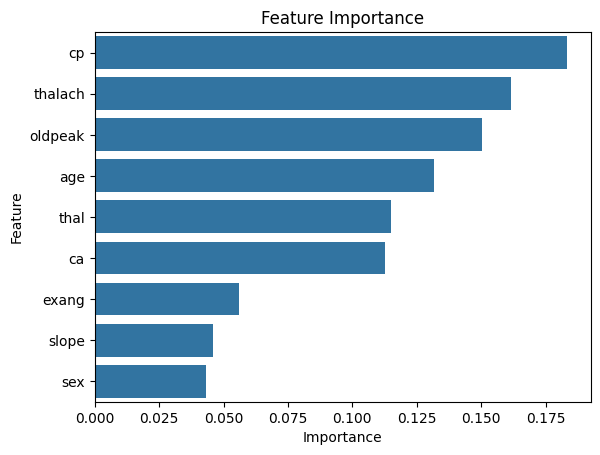

In [123]:
sns.barplot(
    x='Importance',
    y='Feature',
    data=importance
)

plt.title("Feature Importance")

plt.show()

# Best Model Analysis

Based on the evaluation metrics, Random Forest achieved the highest accuracy and F1-score among all models.

Reasons for better performance:

- Random Forest combines multiple decision trees.
- It reduces overfitting through ensemble learning.
- It can capture complex relationships between features.
- It handles feature interactions better than Logistic Regression and KNN.
- It produced the most balanced Precision, Recall, and F1-Score.

# Step 13: Confusion Matrix

The confusion matrix provides a detailed view of the classification performance of the best model.

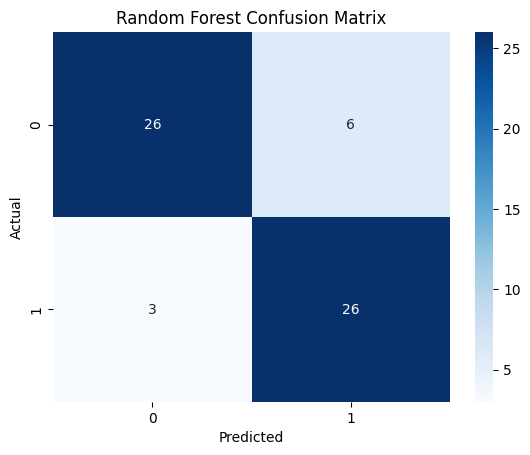

In [124]:
cm = confusion_matrix(
    y_test,
    y_pred_rf
)

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Random Forest Confusion Matrix")

plt.show()

# Step 14: Classification Report

The classification report summarizes precision, recall, F1-score, and support for each class.

In [125]:
print(classification_report(
    y_test,
    y_pred_rf
))

              precision    recall  f1-score   support

           0       0.90      0.81      0.85        32
           1       0.81      0.90      0.85        29

    accuracy                           0.85        61
   macro avg       0.85      0.85      0.85        61
weighted avg       0.86      0.85      0.85        61



# Conclusion

1. Three machine learning algorithms were trained and evaluated for heart disease prediction.

2. Random Forest achieved the highest accuracy and F1-score among all models.

3. Feature importance analysis showed that chest pain type, maximum heart rate, and oldpeak were the most influential predictors.

4. The confusion matrix demonstrated that the model correctly classified most patients with minimal errors.

5. Therefore, Random Forest was selected as the best model due to its strong predictive performance and robustness.